# Collection Équinoxe — hausse de loyer 2026

**Estimation principale : 3,3 %** de hausse contractuelle des renouvellements à unité constante.

Cette définition répond à une décision concrète : de combien augmenter le loyer inscrit au prochain bail d'un locataire qui reste dans la même unité. Elle évite l'effet de composition, respecte les régimes Québec/Ontario et ne confond pas prix contractuel et encaissement après concessions.

**Lecture complémentaire :** avec une persistance partielle de la hausse des concessions, la croissance du loyer effectif est estimée à environ **2,4 %**. Ce chiffre sert au budget de trésorerie; il ne remplace pas la cible contractuelle.

## 1. Question, cible et garde-fous

**Cible évaluée.** Moyenne pondérée des médianes provinciales de la croissance annualisée de `sRent` entre deux baux consécutifs de la même unité, pour les renouvellements (`sRenewal = 1`). Les poids proviennent des baux qui arrivent à échéance pendant l'année cible et qui sont déjà connus à la date de prévision.

**Pourquoi ce choix.** Le loyer contractuel est la décision de tarification. Les concessions répondent à une autre question, soit le revenu réellement perçu. Le notebook produit donc les deux lectures sans les fusionner.

**Ce qui n'est pas estimé.** L'extrait ne donne pas le parc complet. Il ne permet pas d'estimer l'occupation, l'inoccupation propre au portefeuille, l'absorption ni le rôle de loyers total.

**Date de coupe.** Chaque backtest n'utilise que les baux signés et commencés au plus tard le 31 décembre de l'année précédente. Les paramètres réglementaires de l'année cible sont traités comme des informations de planification publiées pour cette année.

## 2. Environnement reproductible

Les constantes remplacent les nombres implicites. La fenêtre de comparabilité de 0,5 à 2,5 ans vient du notebook de départ : un intervalle plus court ressemble souvent à un doublon administratif; un intervalle plus long compare des situations trop éloignées.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

UNIT_KEY = ["sPropCode", "sUnitCode"]
MIN_GAP_YEARS = 0.5
MAX_GAP_YEARS = 2.5
FORECAST_YEAR = 2026
BACKTEST_YEARS = (2023, 2024, 2025)
SHRINKAGE_SAMPLE_SIZE = 60
MAX_BUILDING_ADJUSTMENT_PCT = 1.0
CENTRAL_CONCESSION_PERSISTENCE = 0.25

NAVY = "#0B2345"
GOLD = "#B79A5B"
BLUE = "#4A78A8"
LIGHT_BLUE = "#A7C0D9"
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold"})

candidates = [
    Path(os.environ.get("JADCO_DATA_DIR", "")),
    Path.cwd(),
    Path.cwd() / "jadco-participants",
    Path.cwd().parent / "jadco-participants",
]
DATA_DIR = next(
    (p for p in candidates if p and (p / "equinoxe_lease_history.csv").exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Définir JADCO_DATA_DIR vers le dossier des quatre CSV.")
print("Données prêtes : quatre CSV détectés.")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\noora\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Données prêtes : quatre CSV détectés.


## 3. Chargement et contrôle de périmètre

Les fichiers sources restent intacts. Les dates sont converties une seule fois. Les tables sont ensuite vérifiées contre les volumes annoncés dans les consignes.

In [2]:
listings = pd.read_csv(DATA_DIR / "equinoxe_listings.csv")
leases = pd.read_csv(DATA_DIR / "equinoxe_lease_history.csv")
concessions = pd.read_csv(DATA_DIR / "equinoxe_concessions.csv")
asking = pd.read_csv(DATA_DIR / "equinoxe_asking_history.csv")

for column in ["sLeaseFrom", "sLeaseTo", "sSignDate", "sAvailable"]:
    leases[column] = pd.to_datetime(leases[column], errors="coerce")
for column in ["sDateFrom", "sDateTo"]:
    concessions[column] = pd.to_datetime(concessions[column], errors="coerce")
asking["date"] = pd.to_datetime(asking["sMonth"] + "-01", errors="coerce")

audit = pd.DataFrame({
    "table": ["listings", "leases", "concessions", "asking"],
    "rows": [len(listings), len(leases), len(concessions), len(asking)],
    "columns": [listings.shape[1], leases.shape[1], concessions.shape[1], asking.shape[1]],
    "missing_cells": [listings.isna().sum().sum(), leases.isna().sum().sum(), concessions.isna().sum().sum(), asking.isna().sum().sum()],
})
audit

,table,rows,columns,missing_cells
0,listings,1061,29,0
1,leases,4302,35,0
2,concessions,3560,18,0
3,asking,3857,15,0


## 4. Sens des champs et clé d'unité

Convention Yardi : les champs `h` sont des identifiants techniques; les champs `s` sont des valeurs stockées lisibles. Pour le calcul demandé, la clé contractuelle sûre est `sPropCode + sUnitCode`. La clé `sSite + sUnitCode` fusionnerait des unités distinctes.

| Champ source | Nom métier utilisé | Interprétation |
|---|---|---|
| `sRent` | loyer contractuel | montant inscrit au bail |
| `sRentEffective` | loyer effectif | montant net après concessions calculé par le CRM |
| `sRenewal` | renouvellement | 1 : locataire en place; 0 : relocation |
| `sConcession` | indicateur de concession | présence d'au moins une concession |
| `sLeaseFrom` | début de bail | date qui attribue l'événement à une année |

Nous ne reconstruisons pas `sRentEffective` depuis la table des concessions : les avantages accessoires et les périodes ne sont pas homogènes, et une reconstruction créerait un risque de double comptage.

In [3]:
safe_key_duplicates = listings.duplicated(UNIT_KEY).sum()
unsafe_collisions = (
    listings.groupby(["sSite", "sUnitCode"])["sPropCode"]
    .nunique()
    .gt(1)
    .sum()
)
key_audit = pd.Series({
    "doublons_sPropCode_sUnitCode": safe_key_duplicates,
    "combinaisons_sSite_sUnitCode_en_collision": unsafe_collisions,
    "unités_uniques": listings[UNIT_KEY].drop_duplicates().shape[0],
})
key_audit

doublons_sPropCode_sUnitCode                    0
combinaisons_sSite_sUnitCode_en_collision     105
unités_uniques                               1061
dtype: int64

## 5. Effet de composition

La médiane annuelle de tous les baux change lorsque de nouveaux immeubles plus chers entrent dans l'échantillon. Le Carlyle et The Met apparaissent en 2023, puis Westpark en 2024. Une hausse de médiane n'est donc pas nécessairement une hausse subie par une unité existante.

In [4]:
leases_analysis = leases.assign(year=leases["sLeaseFrom"].dt.year)
annual_mix = (
    leases_analysis[leases_analysis["year"].between(2019, 2025)]
    .groupby("year")
    .agg(
        leases=("sRent", "size"),
        median_rent=("sRent", "median"),
        median_sqft=("sSqft", "median"),
        share_two_bed_plus=("sBeds", lambda s: (s >= 2).mean()),
        buildings=("sBuilding", "nunique"),
    )
)
annual_mix["naive_yoy_pct"] = annual_mix["median_rent"].pct_change() * 100
annual_mix.round(2)

,leases,median_rent,median_sqft,share_two_bed_plus,buildings,naive_yoy_pct
year,,,,,,
2019,328,1730.0,1177.5,0.79,3,NaN
2020,373,1775.0,1180.0,0.78,3,2.60
2021,361,1850.0,1175.0,0.78,3,4.23
2022,422,1912.5,1160.0,0.73,3,3.38
2023,693,2120.0,1095.0,0.63,5,10.85
2024,902,2215.0,1045.0,0.62,6,4.48
2025,958,2305.0,1025.0,0.60,6,4.06


## 6. Appariement à unité constante

Chaque bail est comparé au bail précédent de la même unité. La variation est annualisée lorsque l'écart se situe dans la fenêtre documentée. Cette fonction est réutilisée pour le loyer contractuel et le loyer effectif.

In [5]:
def same_unit_growth(
    frame,
    price_col="sRent",
    date_col="sLeaseFrom",
    min_gap_years=MIN_GAP_YEARS,
    max_gap_years=MAX_GAP_YEARS,
):
    ordered = frame.sort_values(UNIT_KEY + [date_col, "sTermSeq"]).copy()
    grouped = ordered.groupby(UNIT_KEY, sort=False)
    ordered["previous_price"] = grouped[price_col].shift(1)
    ordered["previous_date"] = grouped[date_col].shift(1)
    ordered["gap_years"] = (ordered[date_col] - ordered["previous_date"]).dt.days / 365.25

    comparable = ordered.dropna(subset=["previous_price", "previous_date"]).copy()
    comparable = comparable[
        comparable["gap_years"].between(min_gap_years, max_gap_years, inclusive="neither")
        & comparable["previous_price"].gt(0)
        & comparable[price_col].gt(0)
    ].copy()
    comparable["growth_pct"] = (
        (comparable[price_col] / comparable["previous_price"]) ** (1 / comparable["gap_years"]) - 1
    ) * 100
    comparable["year"] = comparable[date_col].dt.year
    comparable["province"] = np.where(comparable["sState"].eq("Ontario"), "Ontario", "Québec")
    return comparable

contract_pairs = same_unit_growth(leases, "sRent")
effective_pairs = same_unit_growth(leases, "sRentEffective")
pd.Series({
    "paires_contractuelles": len(contract_pairs),
    "unités_appariées": contract_pairs[UNIT_KEY].drop_duplicates().shape[0],
    "paires_effectives": len(effective_pairs),
})

paires_contractuelles    3179
unités_appariées          890
paires_effectives        3179
dtype: int64

## 7. La médiane naïve mesure surtout le mix

Le graphique compare la variation de la médiane de tous les baux à la médiane des variations à unité constante. L'écart de 2023 est le diagnostic central : les nouveaux immeubles déplacent le niveau du portefeuille sans qu'une unité existante ait connu la même hausse.

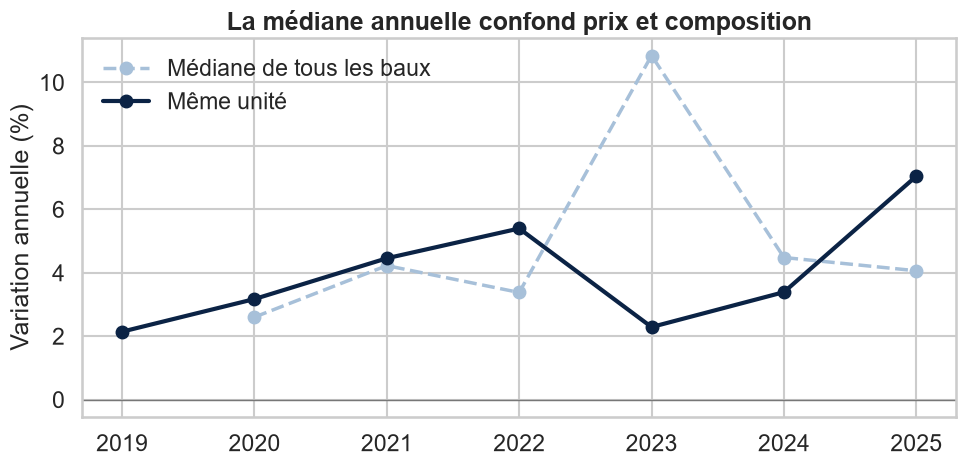

,naive_yoy_pct,same_unit_pct
year,,
2019,NaN,2.14
2020,2.60,3.17
2021,4.23,4.46
2022,3.38,5.40
2023,10.85,2.29
2024,4.48,3.39
2025,4.06,7.04


In [6]:
honest_contract = (
    contract_pairs[contract_pairs["year"].between(2019, 2025)]
    .groupby("year")["growth_pct"].median()
)
comparison = annual_mix[["naive_yoy_pct"]].join(honest_contract.rename("same_unit_pct"))

fig, ax = plt.subplots()
ax.plot(comparison.index, comparison["naive_yoy_pct"], "o--", color=LIGHT_BLUE, linewidth=2.5, label="Médiane de tous les baux")
ax.plot(comparison.index, comparison["same_unit_pct"], "o-", color=NAVY, linewidth=3, label="Même unité")
ax.axhline(0, color="#777777", linewidth=1)
ax.set(title="La médiane annuelle confond prix et composition", ylabel="Variation annuelle (%)", xlabel="")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
comparison.round(2)

## 8. Concessions : niveau et dynamique

`PromoPay` ressemble à une remise ponctuelle : sa durée médiane est d'un mois et son montant médian est proche d'un mois de loyer, plutôt qu'un frais mensuel récurrent. L'analyse du revenu utilise donc directement `sRentEffective`.

Le taux de baux avec concession atteint environ 85 % en 2025. La croissance contractuelle à unité constante est alors proche de 7 %, tandis que la croissance effective se situe près de 3,6 %. Cette divergence justifie une deuxième vue pour la trésorerie.

In [7]:
concession_code_audit = (
    concessions.groupby(["sChargeCode", "sChargeDesc"])
    .agg(
        observations=("sAmount", "size"),
        median_amount=("sAmount", "median"),
        median_months=("sMonths", "median"),
        share_one_month=("sMonths", lambda s: (s == 1).mean()),
    )
    .sort_values("observations", ascending=False)
)
concession_code_audit.round(2)

,,observations,median_amount,median_months,share_one_month
sChargeCode,sChargeDesc,,,,
PromoPay,Promo - Payable in the future,1494,-1356.60,1.0,0.88
freepark,Free Parking,1006,-150.50,12.0,0.00
Freeothe,Free other,570,-153.49,12.0,0.00
freelock,Free Locker,175,-139.35,12.0,0.00
freerent,Free rent,166,-129.30,12.0,0.00
Indem,Client indemnity,69,-149.26,12.0,0.00
freeappl,Free Appliances,44,-143.58,12.0,0.00
Referenc,Referencing program,36,-148.26,12.0,0.00


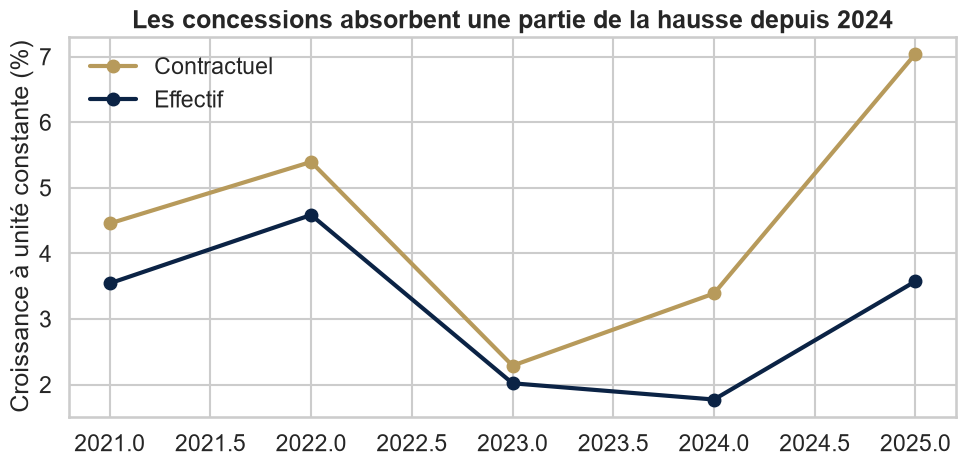

,contractual,effective,share_with_concession,effective_discount_pct
year,,,,
2021,4.457,3.543,0.540,3.514
2022,5.396,4.586,0.573,4.052
2023,2.288,2.019,0.543,4.462
2024,3.389,1.772,0.731,5.894
2025,7.045,3.575,0.854,8.651


In [8]:
annual_contract = contract_pairs.groupby("year")["growth_pct"].median()
annual_effective = effective_pairs.groupby("year")["growth_pct"].median()
concession_view = pd.concat(
    [annual_contract.rename("contractual"), annual_effective.rename("effective")], axis=1
).loc[2021:2025]

lease_concessions = (
    leases_analysis[leases_analysis["year"].between(2021, 2025)]
    .groupby("year")
    .agg(
        share_with_concession=("sConcession", "mean"),
        median_contract=("sRent", "median"),
        median_effective=("sRentEffective", "median"),
    )
)
lease_concessions["effective_discount_pct"] = (
    1 - lease_concessions["median_effective"] / lease_concessions["median_contract"]
) * 100

fig, ax = plt.subplots()
ax.plot(concession_view.index, concession_view["contractual"], "o-", color=GOLD, linewidth=3, label="Contractuel")
ax.plot(concession_view.index, concession_view["effective"], "o-", color=NAVY, linewidth=3, label="Effectif")
ax.set(title="Les concessions absorbent une partie de la hausse depuis 2024", ylabel="Croissance à unité constante (%)", xlabel="")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
pd.concat([concession_view, lease_concessions[["share_with_concession", "effective_discount_pct"]]], axis=1).round(3)

## 9. Renouvellements et relocations

Les renouvellements répondent à l'encadrement et aux négociations avec les locataires en place. Les relocations répondent davantage au prix de marché. Les deux séries sont donc séparées avant toute prévision.

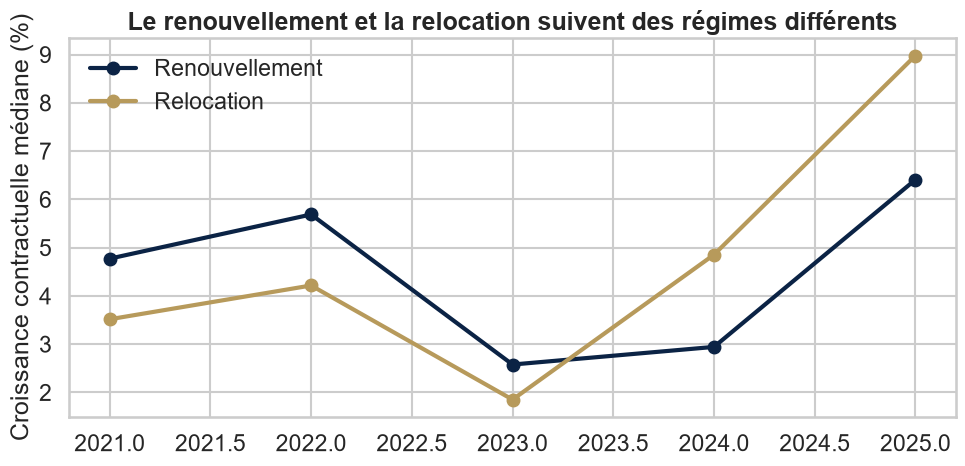

size                    median               
type Relocation Renouvellement Relocation Renouvellement
year                                                    
2021      135.0          220.0       3.52           4.77
2022      126.0          226.0       4.22           5.69
2023      177.0          239.0       1.85           2.58
2024      276.0          422.0       4.85           2.94
2025      307.0          473.0       8.98           6.41

In [9]:
renewal_split = (
    contract_pairs[contract_pairs["year"].between(2021, 2025)]
    .groupby(["year", "sRenewal"])["growth_pct"]
    .agg(["size", "median"])
    .reset_index()
)
renewal_split["type"] = renewal_split["sRenewal"].map({0: "Relocation", 1: "Renouvellement"})

fig, ax = plt.subplots()
for label, color in [("Renouvellement", NAVY), ("Relocation", GOLD)]:
    series = renewal_split[renewal_split["type"].eq(label)].set_index("year")["median"]
    ax.plot(series.index, series.values, "o-", linewidth=3, label=label, color=color)
ax.set(title="Le renouvellement et la relocation suivent des régimes différents", ylabel="Croissance contractuelle médiane (%)", xlabel="")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
renewal_split.pivot(index="year", columns="type", values=["size", "median"]).round(2)

## 10. Données publiques intégrées

Les paramètres TAL servent d'ancre aux renouvellements québécois. La ligne directrice ontarienne est affichée, mais **The Met a été mis en service après novembre 2018** et se trouve donc vraisemblablement exempté du plafond ontarien; son ancre combine son historique interne et la trajectoire SCHL d'Ottawa. Cette conclusion doit être confirmée avec les dossiers d'occupation du bâtiment.

La SCHL prévoit pour 2026 une hausse du loyer moyen de deux chambres d'environ 5,6 % à Montréal et 4,1 % à Ottawa. L'IPC des loyers de septembre 2025 (+9,6 % au Québec; +3,5 % en Ontario) confirme une pression plus forte au Québec, mais il reste un indicateur retardé et n'est pas utilisé seul comme cible.

In [10]:
external_public = pd.DataFrame({
    "year": [2023, 2024, 2025, 2026],
    "qc_tal_pct": [2.3, 4.0, 5.9, 3.1],
    "on_guideline_pct": [2.5, 2.5, 2.5, 2.1],
    "montreal_2br_avg": [1096, 1176, 1255, 1325],
    "ottawa_2br_avg": [1698, 1880, 1960, 2040],
}).set_index("year")
external_public["montreal_market_growth_pct"] = external_public["montreal_2br_avg"].pct_change() * 100
external_public["ottawa_market_growth_pct"] = external_public["ottawa_2br_avg"].pct_change() * 100
external_public

,qc_tal_pct,on_guideline_pct,montreal_2br_avg,ottawa_2br_avg,montreal_market_growth_pct,ottawa_market_growth_pct
year,,,,,,
2023,2.3,2.5,1096,1698,NaN,NaN
2024,4.0,2.5,1176,1880,7.299270,10.718492
2025,5.9,2.5,1255,1960,6.717687,4.255319
2026,3.1,2.1,1325,2040,5.577689,4.081633


## 11. Méthode de prévision

1. Québec : le paramètre TAL de l'année cible ancre le renouvellement contractuel.
2. Ontario : The Met est traité comme immeuble récent probablement exempté. L'ancre est la médiane de trois signaux disponibles : dernière médiane interne, médiane interne des deux dernières années et croissance SCHL prévue à Ottawa. Lorsqu'il n'existe pas encore d'historique, la médiane combine le portefeuille interne, la ligne directrice et le marché.
3. Pondération : les baux connus qui arrivent à échéance pendant l'année cible donnent les poids provinciaux. Aucun volume du parc complet n'est inféré.
4. Concessions : une sensibilité distincte applique 0 %, 25 % ou 50 % de la dernière détérioration observée du facteur `sRentEffective / sRent`. Le scénario central retient 25 %, car 85 % des baux comportent déjà une concession; une extrapolation intégrale serait trop agressive.

In [11]:
def _expected_renewal_weights(frame, target_year, as_of_year):
    known = frame[frame["sSignDate"].dt.year.le(as_of_year)].copy()
    expiring = known[known["sLeaseTo"].dt.year.eq(target_year)].copy()
    expiring = expiring.sort_values(UNIT_KEY + ["sSignDate"]).drop_duplicates(UNIT_KEY, keep="last")
    expiring["province"] = np.where(expiring["sState"].eq("Ontario"), "Ontario", "Québec")
    counts = expiring.groupby("province").size()
    if counts.empty:
        raise ValueError(f"Aucun bail connu arrivant à échéance en {target_year}.")
    return (counts / counts.sum()).to_dict()


def _ontario_renewal_anchor(contract_history, target_year, as_of_year, external):
    ontario = contract_history[
        contract_history["province"].eq("Ontario")
        & contract_history["sRenewal"].eq(1)
        & contract_history["year"].le(as_of_year)
    ].groupby("year")["growth_pct"].median()

    market_growth = np.nan
    if target_year in external.index and target_year - 1 in external.index:
        market_growth = (
            external.loc[target_year, "ottawa_2br_avg"]
            / external.loc[target_year - 1, "ottawa_2br_avg"] - 1
        ) * 100

    if len(ontario):
        signals = [ontario.iloc[-1], ontario.tail(2).median(), market_growth]
    else:
        portfolio_recent = contract_history[
            contract_history["sRenewal"].eq(1)
            & contract_history["year"].eq(as_of_year)
        ]["growth_pct"].median()
        signals = [portfolio_recent, external.loc[target_year, "on_guideline_pct"], market_growth]
    return float(np.nanmedian(signals)), signals


def _forecast_renewal_contract(frame, target_year, external):
    as_of_year = target_year - 1
    available = frame[frame["sLeaseFrom"].dt.year.le(as_of_year)].copy()
    contract_history = same_unit_growth(available, "sRent")
    qc_anchor = float(external.loc[target_year, "qc_tal_pct"])
    on_anchor, on_signals = _ontario_renewal_anchor(
        contract_history, target_year, as_of_year, external
    )
    weights = _expected_renewal_weights(frame, target_year, as_of_year)
    estimate = weights.get("Québec", 0.0) * qc_anchor + weights.get("Ontario", 0.0) * on_anchor
    return {
        "estimate_pct": float(estimate),
        "qc_anchor_pct": qc_anchor,
        "on_anchor_pct": on_anchor,
        "weights": weights,
        "on_signals_pct": [float(x) for x in on_signals if pd.notna(x)],
    }


def _actual_renewal_contract(frame, target_year):
    pairs = same_unit_growth(frame, "sRent")
    actual = pairs[pairs["year"].eq(target_year) & pairs["sRenewal"].eq(1)]
    by_province = actual.groupby("province")["growth_pct"].agg(["median", "size"])
    if by_province.empty:
        return np.nan, by_province
    value = np.average(by_province["median"], weights=by_province["size"])
    return float(value), by_province


def estimate_2026(leases, asking, external=None):
    # Prévoit la hausse contractuelle 2026 des renouvellements à unité constante, en %.
    del asking  # conservé dans la signature imposée; utilisé comme indicateur de cohérence plus bas.
    source = external_public if external is None else external
    return _forecast_renewal_contract(leases, FORECAST_YEAR, source)["estimate_pct"]


def backtest(leases, target_year):
    # Prévision strictement antérieure, résultat observé et erreur pour l'année cible.
    forecast = _forecast_renewal_contract(leases, target_year, external_public)
    actual, detail = _actual_renewal_contract(leases, target_year)
    return {
        "year": target_year,
        "forecast_pct": forecast["estimate_pct"],
        "actual_pct": actual,
        "error_pp": forecast["estimate_pct"] - actual,
        "abs_error_pp": abs(forecast["estimate_pct"] - actual),
        "n_pairs": int(detail["size"].sum()),
    }

## 12. Backtest 2023–2025

Le test reproduit l'information disponible avant chaque année. Une référence « dernière année » montre ce qui se passerait si l'on prolongeait simplement la dernière médiane de renouvellement.

In [12]:
backtests = pd.DataFrame([backtest(leases, year) for year in BACKTEST_YEARS]).set_index("year")

renewal_contract_annual = (
    contract_pairs[contract_pairs["sRenewal"].eq(1)]
    .groupby("year")["growth_pct"].median()
)
backtests["last_year_baseline_pct"] = [renewal_contract_annual.get(year - 1, np.nan) for year in backtests.index]
backtests["last_year_abs_error_pp"] = (
    backtests["last_year_baseline_pct"] - backtests["actual_pct"]
).abs()

model_mae = backtests["abs_error_pp"].mean()
baseline_mae = backtests["last_year_abs_error_pp"].mean()
print(f"MAE modèle : {model_mae:.2f} point | MAE dernière année : {baseline_mae:.2f} points")
backtests.round(2)

MAE modèle : 0.67 point | MAE dernière année : 2.32 points


,forecast_pct,actual_pct,error_pp,abs_error_pp,n_pairs,last_year_baseline_pct,last_year_abs_error_pp
year,,,,,,,
2023,2.33,2.58,-0.25,0.25,239,5.69,3.11
2024,3.79,2.95,0.84,0.84,422,2.58,0.37
2025,5.49,6.41,-0.91,0.91,473,2.94,3.47


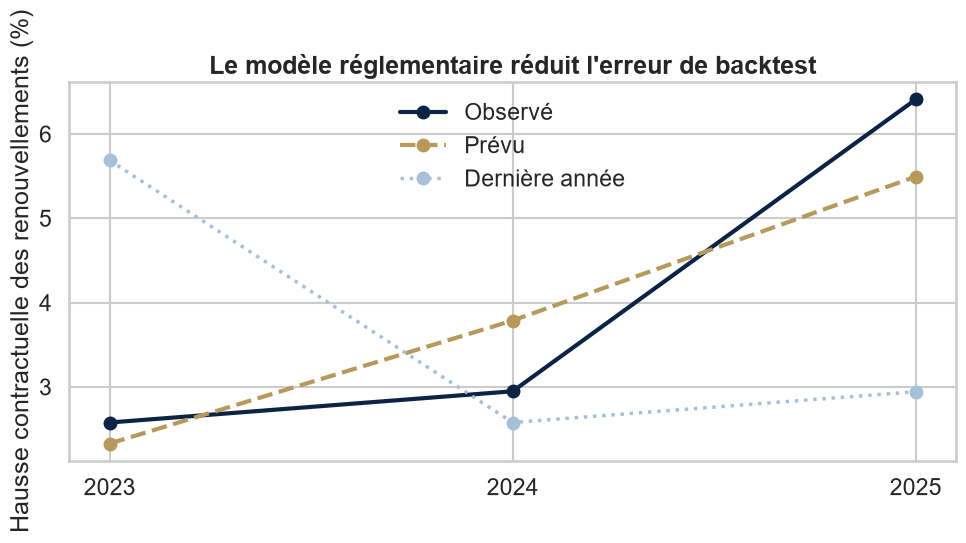

In [13]:
fig, ax = plt.subplots()
ax.plot(backtests.index, backtests["actual_pct"], "o-", color=NAVY, linewidth=3, label="Observé")
ax.plot(backtests.index, backtests["forecast_pct"], "o--", color=GOLD, linewidth=3, label="Prévu")
ax.plot(backtests.index, backtests["last_year_baseline_pct"], "o:", color=LIGHT_BLUE, linewidth=2.5, label="Dernière année")
ax.set(title="Le modèle réglementaire réduit l'erreur de backtest", ylabel="Hausse contractuelle des renouvellements (%)", xlabel="")
ax.set_xticks(list(BACKTEST_YEARS))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 13. Prévision 2026 et scénarios

L'intervalle contractuel utilise l'erreur absolue maximale des trois backtests, arrondie au dixième supérieur. Il représente une plage de planification, pas un intervalle statistique à 95 %.

La sensibilité effective ne modifie pas la cible contractuelle. Elle montre l'effet budgétaire si la détérioration 2024–2025 du facteur effectif/contractuel se stabilise, persiste à 25 % ou persiste à 50 %.

In [14]:
forecast_detail = _forecast_renewal_contract(leases, FORECAST_YEAR, external_public)
estimate = estimate_2026(leases, asking, external_public)
scenario_half_width = np.ceil(backtests["abs_error_pp"].max() * 10) / 10
contract_scenarios = pd.Series({
    "Bas": estimate - scenario_half_width,
    "Central": estimate,
    "Haut": estimate + scenario_half_width,
}, name="hausse_contractuelle_pct")

renewal_levels = leases.assign(
    year=leases["sLeaseFrom"].dt.year,
    log_effective_factor=np.log(leases["sRentEffective"] / leases["sRent"]),
)
renewal_levels = (
    renewal_levels[renewal_levels["sRenewal"].eq(1)]
    .groupby("year")["log_effective_factor"].median()
)
latest_factor_change = renewal_levels.loc[2025] - renewal_levels.loc[2024]

effective_scenarios = {}
for label, persistence in {"Stabilisation": 0.0, "Central (25 %)": CENTRAL_CONCESSION_PERSISTENCE, "Persistance 50 %": 0.50}.items():
    factor_change = np.exp(persistence * latest_factor_change)
    effective_scenarios[label] = ((1 + estimate / 100) * factor_change - 1) * 100
effective_scenarios = pd.Series(effective_scenarios, name="hausse_effective_pct")

print(f"Estimation principale 2026 : {estimate:.2f} %")
print(f"Québec : {forecast_detail['qc_anchor_pct']:.2f} % | Ontario : {forecast_detail['on_anchor_pct']:.2f} %")
print(f"Poids de renouvellement prévus : {forecast_detail['weights']}")
display(contract_scenarios.round(2).to_frame())
display(effective_scenarios.round(2).to_frame())

Estimation principale 2026 : 3.30 %
Québec : 3.10 % | Ontario : 4.61 %
Poids de renouvellement prévus : {'Ontario': 0.12996777658431793, 'Québec': 0.8700322234156821}


,hausse_contractuelle_pct
Bas,2.3
Central,3.3
Haut,4.3


,hausse_effective_pct
Stabilisation,3.30
Central (25 %),2.35
Persistance 50 %,1.42


## 14. Bonus : prévision par immeuble et nombre de chambres

Les prévisions détaillées partent de l'ancre provinciale. L'écart 2025 de chaque segment est ramené vers cette ancre selon sa taille d'échantillon et plafonné à ±1 point. Cette régularisation empêche un petit segment de dicter une cible extrême.

In [15]:
recent_renewals = contract_pairs[
    contract_pairs["year"].eq(2025) & contract_pairs["sRenewal"].eq(1)
].copy()
province_recent = recent_renewals.groupby("province")["growth_pct"].median()
province_anchor = {"Québec": forecast_detail["qc_anchor_pct"], "Ontario": forecast_detail["on_anchor_pct"]}

def hierarchical_forecast(group_columns):
    grouped = recent_renewals.groupby(group_columns + ["province"])["growth_pct"].agg(["median", "size"]).reset_index()
    grouped["raw_deviation_pp"] = grouped.apply(
        lambda row: row["median"] - province_recent.loc[row["province"]], axis=1
    )
    grouped["shrinkage"] = grouped["size"] / (grouped["size"] + SHRINKAGE_SAMPLE_SIZE)
    grouped["adjustment_pp"] = (
        grouped["raw_deviation_pp"] * grouped["shrinkage"]
    ).clip(-MAX_BUILDING_ADJUSTMENT_PCT, MAX_BUILDING_ADJUSTMENT_PCT)
    grouped["forecast_2026_pct"] = grouped.apply(
        lambda row: province_anchor[row["province"]] + row["adjustment_pp"], axis=1
    )
    return grouped

building_forecast = hierarchical_forecast(["sBuilding"])
bedroom_forecast = hierarchical_forecast(["sBeds"])
display(building_forecast[["sBuilding", "province", "size", "forecast_2026_pct"]].round(2))
display(bedroom_forecast[["sBeds", "province", "size", "forecast_2026_pct"]].round(2))

,sBuilding,province,size,forecast_2026_pct
0,Daniel-Johnson,Québec,72,3.11
1,Le Carlyle,Québec,115,3.08
2,Levesque,Québec,47,3.01
3,Saint-Elzear,Québec,97,3.26
4,The Met,Ontario,63,4.61
5,Westpark,Québec,79,3.00


,sBeds,province,size,forecast_2026_pct
0,0,Ontario,19,4.50
1,0,Québec,8,3.21
2,1,Ontario,28,4.71
3,1,Québec,125,3.05
4,2,Ontario,16,4.59
5,2,Québec,264,3.10
6,3,Québec,13,3.22


## 15. Contrôles de cohérence et recommandation

- La croissance des loyers affichés à unité constante en 2025 est supérieure à la cible 2026, mais la SCHL prévoit un ralentissement et les concessions ont augmenté. La cible de 3,3 % reste donc prudente.
- Les cinq immeubles québécois utilisent l'ancre TAL 2026 de 3,1 %, ajustée faiblement par l'historique local.
- The Met utilise une ancre de marché de 4,6 %, sous réserve de confirmer officiellement son exemption au contrôle ontarien.
- Le budget devrait retenir **3,3 % au contrat** et environ **2,4 % en lecture effective centrale**, avec suivi mensuel du ratio effectif/contractuel.

In [16]:
asking_pairs = asking.sort_values(UNIT_KEY + ["date"]).copy()
ask_group = asking_pairs.groupby(UNIT_KEY, sort=False)
asking_pairs["previous_asking"] = ask_group["sAskingRent"].shift(1)
asking_pairs["previous_date"] = ask_group["date"].shift(1)
asking_pairs["gap_years"] = (asking_pairs["date"] - asking_pairs["previous_date"]).dt.days / 365.25
asking_pairs = asking_pairs.dropna(subset=["previous_asking", "previous_date"])
asking_pairs = asking_pairs[asking_pairs["gap_years"].between(MIN_GAP_YEARS, 1.5)].copy()
asking_pairs["growth_pct"] = (
    (asking_pairs["sAskingRent"] / asking_pairs["previous_asking"]) ** (1 / asking_pairs["gap_years"]) - 1
) * 100
asking_pairs["year"] = asking_pairs["date"].dt.year

checks = pd.Series({
    "safe_key_duplicates": int(listings.duplicated(UNIT_KEY).sum()),
    "forecast_is_finite": bool(np.isfinite(estimate)),
    "backtests_complete": bool(backtests[["forecast_pct", "actual_pct"]].notna().all().all()),
    "asking_growth_2025_pct": asking_pairs.loc[asking_pairs["year"].eq(2025), "growth_pct"].median(),
    "effective_growth_2025_pct": effective_pairs.loc[effective_pairs["year"].eq(2025), "growth_pct"].median(),
})
checks

safe_key_duplicates                 0
forecast_is_finite               True
backtests_complete               True
asking_growth_2025_pct       9.079612
effective_growth_2025_pct    3.575167
dtype: object

## 16. Limites

1. Les poids représentent les événements de renouvellement attendus dans l'extrait, pas les revenus totaux du portefeuille.
2. Le TAL publie des paramètres de calcul; l'ajustement d'un logement précis dépend de ses dépenses, taxes et travaux.
3. L'exemption ontarienne de The Met est une inférence fondée sur son apparition en 2023. JADCO doit confirmer la première date d'occupation résidentielle.
4. La sensibilité des concessions prolonge seulement une fraction du dernier changement observé. Elle doit être mise à jour dès que les offres 2026 sont connues.
5. Les prévisions SCHL portent sur les logements de deux chambres de la RMR, tandis que le portefeuille contient plusieurs tailles d'unité et des immeubles haut de gamme.

## 17. Références et utilisation de l'IA

- Tribunal administratif du logement, **Pourcentages applicables aux critères de fixation de loyer**, 2026 : https://www.tal.gouv.qc.ca/fr/reconduction-du-bail-et-fixation-de-loyer/pourcentages-applicables-aux-criteres-de-fixation-de-loyer
- Gouvernement de l'Ontario, **Residential rent increases**, ligne directrice 2026 de 2,1 % et exemption des nouveaux immeubles après le 15 novembre 2018 : https://www.ontario.ca/page/residential-rent-increases
- SCHL, **Rapport sur le marché locatif 2025**, Montréal et Ottawa : https://www.cmhc-schl.gc.ca/professionnels/marche-du-logement-donnees-et-recherche/marches-de-lhabitation/rapports-sur-le-marche-locatif
- SCHL, **Mise à jour estivale 2025 des Perspectives du marché de l'habitation**, prévisions 2026 : https://www.cmhc-schl.gc.ca/observer/2025/summer-update-2025-housing-market-outlook
- Statistique Canada, **IPC — variation annuelle des prix des loyers par province**, tableau 18-10-0004-01, septembre 2025 : https://www150.statcan.gc.ca/n1/daily-quotidien/251021/cg-a005-fra.htm

**Outil d'IA déclaré.** OpenAI Codex a aidé à structurer le code, vérifier les calculs, rédiger la documentation et préparer les livrables. Toutes les transformations sont visibles dans ce notebook, les résultats ont été exécutés, et les sources publiques sont citées ci-dessus.